INFO     | ======================================================================
INFO     | Starting analysis: figure_02_SIV_decomposition
INFO     | Log file: outputs/logs/figure_02_SIV_decomposition_20260622_123850.log
INFO     | Timestamp: 2026-06-22 12:38:50
INFO     | ======================================================================
INFO     | Configuration loaded
INFO     | TREND_MODE = 'components_only'
INFO     | Loading GLORYS12 data from: ../../glorys12_with_density/glorys12_*_Greenland_Sea_with_density.nc
INFO     | Time: 1993-01-01 -> 2025-11-01
INFO     | Processing: Creating Greenland Sea mask
INFO     | Masked cells: 30496
INFO     | Processing: Computing per-cell SIV budget
INFO     |   Grid: dy=9.27 km, dx 1.77-3.02 km
INFO     |   Computing flux divergence (centred differences)...
INFO     |   Computing dSIV/dt per cell...
INFO     |   Computing (this may take several minutes)...
INFO     |   Domain closure: max |residual| = 0.000000 km3
INFO     | Created netcd

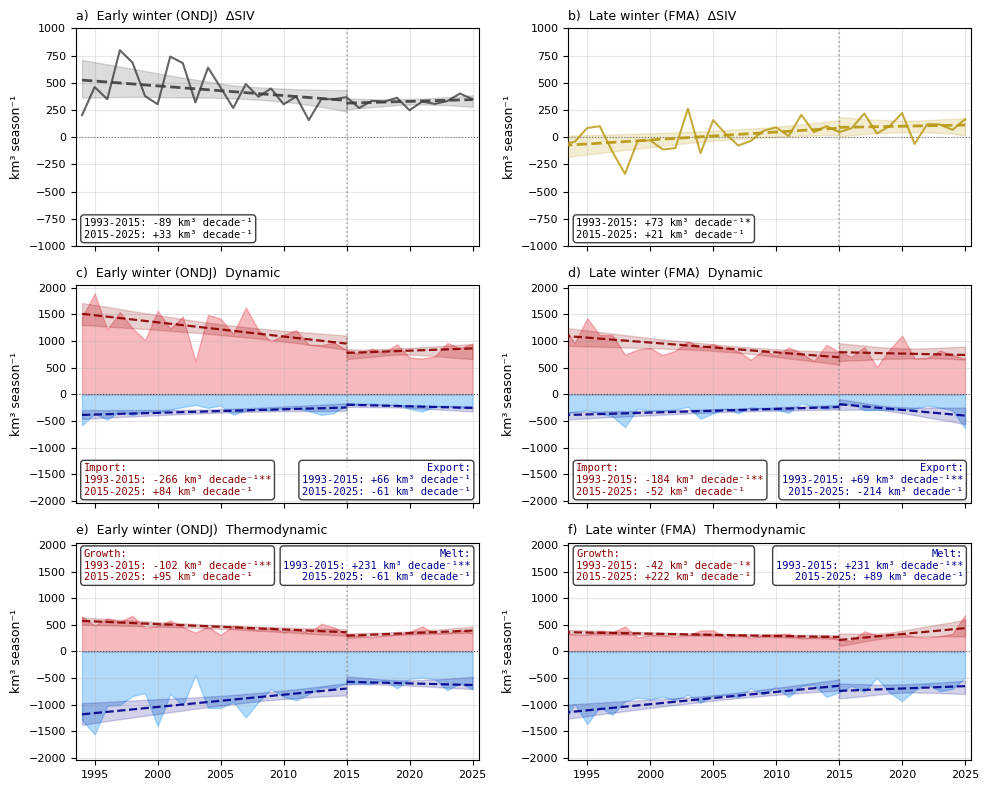

INFO     | Created methods: figure_02_SIV_decomposition_methods.md
INFO     | Methods written: outputs/methods/figure_02_SIV_decomposition_methods.md
INFO     | ======================================================================
INFO     | Analysis completed successfully
INFO     | Total elapsed time: 0:00:16
INFO     | ======================================================================
INFO     | COMPLETE


In [1]:
"""
Figure 2: SIV decomposition
================================
Script producing the Greenland Sea SIV budget timeseries figure.

Layout: 3 rows × 2 cols
  Rows: (a/b) dSIV/dt  |  (c/d) Dynamic (import / export)  |  (e/f) Thermodynamic (growth / melt)
  Cols: ONDJ (left)  |  FMA (right)

Method
------
Per-grid-cell SIV budget decomposition:

    dSIV_cell/dt = dynamic_cell + thermo_cell

where:
  dynamic_cell  = -∇.(u x h x c)   centred-difference divergence, negated
                  so positive = net ice gained by advection
  thermo_cell   = dSIV_cell - dynamic_cell   (residual)
                  positive = local growth, negative = local melt

Domain-integrated timeseries are partitioned by sign before seasonal
aggregation, giving gross import/export and gross growth/melt separately.

Processing is cached to NetCDF so subsequent runs with REPROCESS=False
skip the expensive computation entirely.

Note: SEC_PER_MONTH uses a fixed 30-day approximation (86400 * 30 s).
This introduces a small error (~3%) relative to calendar-exact month
lengths and should be updated in a future revision.

Outputs
-------
  ./outputs/figures/figure_02_SIV_decomposition.png
  ./outputs/processed_data/figure_02/
      siv_budget_monthly.nc          -- (time, lat, lon): d_siv, div, thermo
      domain_growth_melt_early.csv   -- seasonal ONDJ domain-integrated series
      domain_growth_melt_late.csv    -- seasonal FMA  domain-integrated series
  ./outputs/methods/figure_02_SIV_decomposition_methods.md

Version: 2.1.0
Last Modified: 22-06-2026
Author : Chris Barrell
"""

import sys
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import xarray as xr
import shapely.geometry as sgeom
import regionmask
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from scipy import stats as scipy_stats

warnings.filterwarnings('ignore')

sys.path.append('..')
from utils.logger import (setup_logger, log_data_loading, log_processing_step,
                          log_output_file, log_completion, log_error)

logger = setup_logger('figure_02_SIV_decomposition', config_path='../config.yaml')
start_time = datetime.now()

try:
    # ========================================================================
    # CONFIGURATION
    # ========================================================================

    GLORYS_PATH = '../../glorys12_with_density/glorys12_*_Greenland_Sea_with_density.nc'

    OUTPUT_FIG_DIR     = Path('./outputs/figures')
    OUTPUT_DATA_DIR    = Path('./outputs/processed_data/figure_02')
    OUTPUT_METHODS_DIR = Path('./outputs/methods')
    OUTPUT_FIG_DIR.mkdir(parents=True, exist_ok=True)
    OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)
    OUTPUT_METHODS_DIR.mkdir(parents=True, exist_ok=True)

    # Greenland Sea polygon -- must match figure_02.py
    GREENLAND_SEA_COORDS = [
        (-22,   71),
        ( -8.5, 71),
        ( 12,   79),
        (-21,   79),
        (-28,   73),
        (-22,   71),
    ]

    # Season definitions
    EARLY_WINTER_MONTHS = [10, 11, 12, 1]   # ONDJ
    LATE_WINTER_MONTHS  = [2,  3,  4]        # FMA

    # Trend split
    SPLIT_YEAR    = 2015
    PERIOD1_YEARS = (1993, 2015)
    PERIOD2_YEARS = (2015, 2025)

    # ---- Processing --------------------------------------------------------
    # REPROCESS=False loads the cached monthly NetCDF and skips all heavy
    # computation. Set True to recompute from raw GLORYS12 files.
    REPROCESS = False

    # Bootstrap parameters for trend CI
    N_BOOTSTRAP = 1000
    CI_LEVEL    = 0.95

    # ---- Trend line display on panels c-f ----------------------------------
    # 'all'             -- component trends (import/export or growth/melt) + net
    # 'components_only' -- component trends only, no net trend line
    # 'net_only'        -- net trend line only
    TREND_MODE = 'components_only'   # 'all' | 'components_only' | 'net_only'

    # ---- Figure style ------------------------------------------------------
    COLOR_EARLY  = '#3D3D3D'
    COLOR_LATE   = '#B8960C'
    COLOR_BP     = '#808080'
    C_GAIN       = '#E63946'    # red fill   -- ice gain
    C_LOSS       = '#2196F3'    # blue fill  -- ice loss
    C_GAIN_DARK  = '#8B0000'    # dark red   -- gain trend line
    C_LOSS_DARK  = '#00008B'    # dark blue  -- loss trend line
    UNIT_STR     = 'km\u00b3\u00a0decade\u207b\u00b9'   # km3 decade-1

    DPI = 600

    logger.info("Configuration loaded")
    logger.info(f"TREND_MODE = '{TREND_MODE}'")

    # ========================================================================
    # UTILITY FUNCTIONS
    # ========================================================================

    def haversine_m(lat1, lon1, lat2, lon2):
        """Haversine distance in metres."""
        R = 6_371_000.0
        ph1, ph2 = np.radians(lat1), np.radians(lat2)
        dph = np.radians(lat2 - lat1)
        dlm = np.radians(lon2 - lon1)
        a = np.sin(dph/2)**2 + np.cos(ph1)*np.cos(ph2)*np.sin(dlm/2)**2
        return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))


    def get_season_year(time_da, is_early):
        """Assign winter-year label to each timestep.
        Early winter (ONDJ): Oct-Dec are labelled as the following year's season.
        Late winter (FMA):   year label = calendar year as-is.
        """
        year  = time_da.dt.year.values.copy()
        month = time_da.dt.month.values
        if is_early:
            year[month >= 10] += 1
        return year


    def seasonal_sum_1d(da, months, is_early, label=''):
        """Seasonal sums of a 1-D (time,) DataArray for complete seasons only.

        Completeness is assessed from the season-year coordinate count alone
        so no data values are inspected (avoids issues with masked/NaN cells).
        """
        n_expected = len(months)

        # Select months belonging to this season
        month_mask = da.time.dt.month.isin(months)
        da_s = da.sel(time=month_mask)

        # Assign season-year label to each timestep
        sy = get_season_year(da_s.time, is_early)
        da_s = da_s.assign_coords(sy=('time', sy))

        # Identify complete seasons from label counts (no data access)
        unique_sy, sy_counts = np.unique(sy, return_counts=True)
        complete = unique_sy[sy_counts == n_expected]

        # Select only complete-season timesteps, re-assign sy, then group-sum
        time_keep = da_s.time.values[np.isin(sy, complete)]
        sy_keep   = sy[np.isin(sy, complete)]
        da_s = da_s.sel(time=time_keep).assign_coords(sy=('time', sy_keep))
        sums = da_s.groupby('sy').sum('time').rename({'sy': 'year'})

        if label:
            logger.info(f"  {label}: {int(sums.year.values[0])}"
                        f"-{int(sums.year.values[-1])}, n={len(sums.year)}")
        return sums


    def piecewise_trends(ax, yrs, vals, line_color, split, lw=2.0,
                         n_boot=N_BOOTSTRAP, ci=CI_LEVEL):
        """Fit and plot OLS trend lines with bootstrap CI for two sub-periods.

        For each period (P1: start-split, P2: split-end):
          1. Select data points in the period, drop NaNs.
          2. Fit OLS line (scipy linregress) in raw year coordinates.
          3. Bootstrap n_boot resampled OLS fits for a CI band.
          4. Plot dashed trend line and shaded CI band on ax.
          5. Compute Mann-Kendall significance (standard variant; appropriate
             for annual/seasonal series).

        Returns list of two stats strings (one per period), e.g.:
            '1993-2015: +123 km3 decade-1 *'
        """
        stats_lines = []
        rng = np.random.default_rng(seed=42)

        for _m, _pl in [(yrs <= split, f'{PERIOD1_YEARS[0]}-{split}'),
                        (yrs >= split, f'{split}-{PERIOD2_YEARS[1]}')]:

            # Select period, drop NaNs
            xv = yrs[_m]; yv = vals[_m]
            good = np.isfinite(yv)
            if good.sum() < 3:
                continue
            xg = xv[good]; yg = yv[good]

            # OLS fit in raw year coordinates
            sl, ic, *_ = scipy_stats.linregress(xg, yg)
            fitted = sl * xg + ic

            # Bootstrap CI: resample (x, y) pairs, refit, evaluate at xg
            boot_fits = np.zeros((n_boot, len(xg)))
            for b in range(n_boot):
                idx = rng.choice(len(xg), size=len(xg), replace=True)
                sl_b, ic_b, *_ = scipy_stats.linregress(xg[idx], yg[idx])
                boot_fits[b] = sl_b * xg + ic_b
            alpha = (1 - ci) / 2
            ci_lo = np.percentile(boot_fits, alpha * 100,       axis=0)
            ci_hi = np.percentile(boot_fits, (1 - alpha) * 100, axis=0)

            # Plot CI band and trend line
            ax.fill_between(xg, ci_lo, ci_hi, color=line_color,
                            alpha=0.18, zorder=4)
            ax.plot(xg, fitted, '--', color=line_color, lw=lw,
                    alpha=0.9, zorder=5)

            # Mann-Kendall significance (standard; seasonal/annual series)
            _, p_mk = scipy_stats.kendalltau(xg, yg)
            sig = '**' if p_mk < 0.01 else '*' if p_mk < 0.05 else ''
            stats_lines.append(f'{_pl}: {sl*10:+.0f} {UNIT_STR}{sig}')

        return stats_lines


    def add_stats_box(ax, x, y, lines, color, va, ha):
        """Place a monospace stats text box at axes-fraction position (x, y)."""
        ax.text(x, y, '\n'.join(lines), transform=ax.transAxes,
                fontsize=7.5, va=va, ha=ha, fontfamily='monospace',
                color=color, bbox=dict(boxstyle='round', fc='white', alpha=0.75))


    def write_methods():
        """Write minimal methodology notes for figure_02_SIV_decomposition."""
        methods_file = OUTPUT_METHODS_DIR / 'figure_02_SIV_decomposition_methods.md'
        lines = [
            '# Figure 02 — SIV Decomposition: Methodology Notes',
            '',
            '## Data',
            'GLORYS12V1 ocean reanalysis (Lellouche et al., 2021); 1/12° horizontal',
            'grid; variables: `siconc`, `sithick`, `usi`, `vsi`, `cell_area`.',
            'Period: 1993–2025.',
            '',
            '## Domain',
            'Greenland Sea polygon: (−22°E, 71°N), (−8.5°E, 71°N), (12°E, 79°N),',
            '(−21°E, 79°N), (−28°E, 73°N). Applied as a 2-D regionmask.',
            '',
            '## Budget decomposition',
            'Per-cell SIV (km³) = siconc × sithick × cell_area / 1e9.',
            '',
            'Monthly change: dSIV_cell = SIV_cell.diff(time).',
            '',
            'Dynamic term (centred-difference flux divergence, negated so',
            'positive = net advective gain):',
            '',
            '    dynamic_cell = −∇·(u × h × c) × cell_area × SEC_PER_MONTH / 1e9',
            '',
            'where SEC_PER_MONTH = 86400 × 30 s (fixed 30-day approximation).',
            '',
            'Thermodynamic residual: thermo_cell = dSIV_cell − dynamic_cell',
            '(positive = local growth, negative = local melt).',
            '',
            '## Sign partitioning',
            'Domain-integrated gross terms computed by summing positive and negative',
            'cell contributions separately before seasonal aggregation:',
            '  dynamic import  = Σ max(dynamic_cell, 0)',
            '  dynamic export  = Σ min(dynamic_cell, 0)',
            '  thermo growth   = Σ max(thermo_cell,  0)',
            '  thermo melt     = Σ min(thermo_cell,  0)',
            '',
            '## Seasonal aggregation',
            'Early winter: ONDJ (Oct–Jan); seasons labelled by year of January.',
            'Late winter:  FMA  (Feb–Apr); seasons labelled by calendar year.',
            'Incomplete seasons excluded.',
            '',
            '## Trend analysis',
            'OLS split at 2015; 95% bootstrap CI (n=1000, seed=42).',
            'Significance: standard Mann-Kendall (scipy.stats.kendalltau);',
            '* p<0.05, ** p<0.01.',
        ]
        methods_file.write_text('\n'.join(lines))
        log_output_file(logger, 'methods', methods_file)
        logger.info(f"Methods written: {methods_file}")
        return methods_file

    # ========================================================================
    # 1. LOAD DATA
    # ========================================================================

    log_data_loading(logger, 'GLORYS12', GLORYS_PATH)
    ds = xr.open_mfdataset(GLORYS_PATH, parallel=False)
    logger.info(f"Time: {str(ds.time.values[0])[:10]} "
                f"-> {str(ds.time.values[-1])[:10]}")

    # ========================================================================
    # 2. GREENLAND SEA MASK
    # ========================================================================

    log_processing_step(logger, "Creating Greenland Sea mask")
    poly    = sgeom.Polygon(GREENLAND_SEA_COORDS)
    region  = regionmask.Regions([poly], names=["Greenland Sea"], abbrevs=["GS"])
    mask_2d = (region.mask(ds['longitude'], ds['latitude']) == 0)
    logger.info(f"Masked cells: {int(mask_2d.sum().values)}")

    # ========================================================================
    # 3. PER-CELL BUDGET  (or load from cache)
    # ========================================================================

    cache_file = OUTPUT_DATA_DIR / 'siv_budget_monthly.nc'

    if not REPROCESS and cache_file.exists():
        logger.info(f"Loading cached monthly budget from {cache_file}")
        budget    = xr.open_dataset(cache_file)
        d_siv_2d  = budget['d_siv']
        div_2d    = budget['div']
        thermo_2d = budget['thermo']

    else:
        log_processing_step(logger, "Computing per-cell SIV budget")

        # Cell face widths (vary with latitude for zonal dimension)
        lats     = ds['latitude'].values
        lons     = ds['longitude'].values
        dlon_deg = float(lons[1] - lons[0])
        dlat_deg = float(lats[1] - lats[0])
        dx_m     = np.array([haversine_m(lat, 0.0, lat, dlon_deg) for lat in lats])
        dy_m     = haversine_m(0.0, 0.0, dlat_deg, 0.0)
        dx_da    = xr.DataArray(dx_m, dims='latitude',
                                coords={'latitude': ds['latitude']})
        logger.info(f"  Grid: dy={dy_m/1000:.2f} km, "
                    f"dx {dx_m.min()/1000:.2f}-{dx_m.max()/1000:.2f} km")

        # Ice volume flux density (m2/s = velocity x thickness x concentration)
        Fx = ds['usi'] * ds['sithick'] * ds['siconc']   # eastward
        Fy = ds['vsi'] * ds['sithick'] * ds['siconc']   # northward

        # Centred-difference flux divergence for cell-centred velocities:
        #   div_x[i] = (Fx[i+1] - Fx[i-1]) / (2*dx)
        #   div_y[j] = (Fy[j+1] - Fy[j-1]) / (2*dy)
        # shift(dim=-1): position i reads from i+1 (east/north neighbour)
        # shift(dim=+1): position i reads from i-1 (west/south neighbour)
        # shift (not roll) ensures NaN padding at edges rather than wrap-around.
        logger.info("  Computing flux divergence (centred differences)...")
        dFx_dx = (Fx.shift(longitude=-1) - Fx.shift(longitude=+1)) / (2.0 * dx_da)
        dFy_dy = (Fy.shift(latitude=-1)  - Fy.shift(latitude=+1))  / (2.0 * dy_m)

        SEC_PER_MONTH = 86400 * 30  # fixed 30-day approximation; see docstring note
        div_km3 = (dFx_dx + dFy_dy) * ds['cell_area'] * SEC_PER_MONTH / 1e9

        # dSIV/dt per cell (km3/month)
        logger.info("  Computing dSIV/dt per cell...")
        sivol_cell = ds['siconc'] * ds['sithick'] * ds['cell_area'] / 1e9
        d_siv_cell = sivol_cell.diff(dim='time')

        # Align divergence to d_siv time axis (diff removes first timestep).
        # Negate divergence so that dynamic_cell > 0 means net ice gained
        # by advection (inflow-positive convention).
        div_aligned  = div_km3.sel(time=d_siv_cell.time)
        dynamic_cell = -div_aligned

        # Thermodynamic residual: thermo > 0 = growth, thermo < 0 = melt
        thermo_cell  = d_siv_cell - dynamic_cell

        # Apply mask and compute
        logger.info("  Computing (this may take several minutes)...")
        d_siv_2d  = d_siv_cell.where(mask_2d).compute()
        div_2d    = dynamic_cell.where(mask_2d).compute()
        thermo_2d = thermo_cell.where(mask_2d).compute()

        # Sanity check: domain sum residual should be ~0 by construction
        residual = (d_siv_2d - div_2d - thermo_2d).sum(dim=['latitude','longitude'])
        logger.info(f"  Domain closure: "
                    f"max |residual| = {float(np.abs(residual).max()):.6f} km3")

        d_siv_2d.attrs  = {'long_name': 'Monthly SIV change per cell',
                            'units': 'km3/month'}
        div_2d.attrs    = {'long_name': 'Dynamic SIV contribution per cell',
                            'units': 'km3/month',
                            'note': 'inflow-positive'}
        thermo_2d.attrs = {'long_name': 'Thermodynamic residual per cell',
                            'units': 'km3/month',
                            'note': 'positive = growth, negative = melt'}

        xr.Dataset({'d_siv': d_siv_2d, 'div': div_2d, 'thermo': thermo_2d}) \
          .to_netcdf(cache_file)
        log_output_file(logger, 'netcdf', cache_file)
        logger.info(f"  Saved: {cache_file}")

    # ========================================================================
    # 4. DOMAIN-INTEGRATED SIGN-PARTITIONED TIMESERIES
    # ========================================================================

    log_processing_step(logger, "Domain-integrated growth/melt partition")

    # Sign-partition BEFORE spatial summation to preserve gross terms.
    # Gross growth = sum of cells with positive thermo (net growth this month)
    # Gross melt   = sum of cells with negative thermo (net melt this month)
    # Similarly for dynamic import (positive div) and export (negative div).
    thermo_growth = thermo_2d.clip(min=0).sum(dim=['latitude','longitude']).compute()
    thermo_melt   = thermo_2d.clip(max=0).sum(dim=['latitude','longitude']).compute()
    div_import    = div_2d.clip(min=0).sum(dim=['latitude','longitude']).compute()
    div_export    = div_2d.clip(max=0).sum(dim=['latitude','longitude']).compute()
    dsiv_domain   = d_siv_2d.sum(dim=['latitude','longitude']).compute()

    # ========================================================================
    # 5. SEASONAL AGGREGATION
    # ========================================================================

    log_processing_step(logger, "Seasonal aggregation")

    early_ts = {}
    late_ts  = {}
    for name, da in [('dsiv',          dsiv_domain),
                     ('div_import',    div_import),
                     ('div_export',    div_export),
                     ('thermo_growth', thermo_growth),
                     ('thermo_melt',   thermo_melt)]:
        early_ts[name] = seasonal_sum_1d(da, EARLY_WINTER_MONTHS, True,
                                         f'{name} ONDJ')
        late_ts[name]  = seasonal_sum_1d(da, LATE_WINTER_MONTHS,  False,
                                         f'{name} FMA')

    # ========================================================================
    # 6. SAVE TIMESERIES CSVs
    # ========================================================================

    for season_label, ts_dict in [('early', early_ts), ('late', late_ts)]:
        yrs = ts_dict['dsiv'].year.values
        csv_path = OUTPUT_DATA_DIR / f'domain_growth_melt_{season_label}.csv'
        pd.DataFrame({
            'year':          yrs,
            'dsiv':          ts_dict['dsiv'].values,
            'div_import':    ts_dict['div_import'].values,
            'div_export':    ts_dict['div_export'].values,
            'thermo_growth': ts_dict['thermo_growth'].values,
            'thermo_melt':   ts_dict['thermo_melt'].values,
        }).to_csv(csv_path, index=False)
        log_output_file(logger, 'csv', csv_path)

    # ========================================================================
    # 7. FIGURE
    # ========================================================================

    log_processing_step(logger, f"Building figure  (TREND_MODE='{TREND_MODE}')")

    # Determine whether component and/or net trends are shown on panels c-f
    show_comp = TREND_MODE in ('all', 'components_only')
    show_net  = TREND_MODE in ('all', 'net_only')

    # Global y-axis range from all panel data (rows 1 and 2 share this range)
    all_vals = []
    for ts in [early_ts, late_ts]:
        for k in ['div_import', 'div_export', 'thermo_growth', 'thermo_melt']:
            all_vals.extend([float(np.nanmin(ts[k].values)),
                             float(np.nanmax(ts[k].values))])
    y_abs = max(abs(min(all_vals)), abs(max(all_vals))) * 1.08

    fig, axes = plt.subplots(3, 2, figsize=(10, 8), sharex=True)
    fig.subplots_adjust(hspace=0.10, wspace=0.22)

    col_items = [
        ('Early winter (ONDJ)', early_ts, COLOR_EARLY),
        ('Late winter (FMA)',   late_ts,  COLOR_LATE),
    ]
    panel_letters = ['a', 'b', 'c', 'd', 'e', 'f']

    for col_idx, (label_str, ts, color) in enumerate(col_items):

        yrs = ts['dsiv'].year.values.astype(float)

        # ----------------------------------------------------------------
        # Row 0: total dSIV
        # ----------------------------------------------------------------
        ax = axes[0, col_idx]
        vals = ts['dsiv'].values
        ax.plot(yrs, vals, color=color, lw=1.5, alpha=0.8, zorder=3)

        # Trend always shown on row 0
        st = piecewise_trends(ax, yrs, vals, color, SPLIT_YEAR)
        add_stats_box(ax, 0.02, 0.03, st, 'black', va='bottom', ha='left')

        ax.axhline(0, color='k', ls=':', lw=0.8, alpha=0.5)
        ax.axvline(SPLIT_YEAR, color=COLOR_BP, ls=':', lw=1.2, alpha=0.6)
        ax.set_ylim(-1000, 1000)
        ax.set_ylabel('km\u00b3 season\u207b\u00b9', fontsize=9)
        ax.set_title(f'{panel_letters[col_idx]})  {label_str}  ΔSIV',
                     loc='left', fontsize=9)
        ax.grid(alpha=0.3)
        ax.tick_params(labelsize=8)

        # ----------------------------------------------------------------
        # Row 1: dynamic import / export
        # ----------------------------------------------------------------
        ax = axes[1, col_idx]
        yrs_d   = ts['div_import'].year.values.astype(float)
        imp_v   = ts['div_import'].values
        exp_v   = ts['div_export'].values
        net_dyn = imp_v + exp_v

        # Filled areas for gross import (red) and export (blue)
        ax.fill_between(yrs_d, imp_v,   0, color=C_GAIN, alpha=0.35)
        ax.fill_between(yrs_d, exp_v,   0, color=C_LOSS, alpha=0.35)
        # Net dynamic line: only shown when show_net is True
        if show_net:
            ax.plot(yrs_d, net_dyn, color='k', lw=1.2, alpha=0.9, zorder=3)

        # Trend lines according to TREND_MODE
        imp_stats = (piecewise_trends(ax, yrs_d, imp_v,   C_GAIN_DARK,
                                      SPLIT_YEAR, lw=1.6)
                     if show_comp else [])
        exp_stats = (piecewise_trends(ax, yrs_d, exp_v,   C_LOSS_DARK,
                                      SPLIT_YEAR, lw=1.6)
                     if show_comp else [])
        net_stats = (piecewise_trends(ax, yrs_d, net_dyn, 'k',
                                      SPLIT_YEAR, lw=1.8)
                     if show_net else [])

        # Stats boxes: Import BL, Export BR; Net TR only when show_net
        add_stats_box(ax, 0.02, 0.03, ['Import:'] + imp_stats,
                      C_GAIN_DARK, va='bottom', ha='left')
        add_stats_box(ax, 0.98, 0.03, ['Export:'] + exp_stats,
                      C_LOSS_DARK, va='bottom', ha='right')
        if show_net:
            add_stats_box(ax, 0.98, 0.97, ['Net:'] + net_stats,
                          'k', va='top', ha='right')

        ax.axhline(0, color='k', ls=':', lw=0.8, alpha=0.5)
        ax.axvline(SPLIT_YEAR, color=COLOR_BP, ls=':', lw=1.2, alpha=0.6)
        ax.set_ylim(-y_abs, y_abs)
        ax.set_ylabel('km\u00b3 season\u207b\u00b9', fontsize=9)
        ax.set_title(f'{panel_letters[col_idx+2]})  {label_str}  Dynamic',
                     loc='left', fontsize=9)
        ax.grid(alpha=0.3)
        ax.tick_params(labelsize=8)

        # ----------------------------------------------------------------
        # Row 2: thermodynamic growth / melt
        # ----------------------------------------------------------------
        ax = axes[2, col_idx]
        yrs_t      = ts['thermo_growth'].year.values.astype(float)
        grow_v     = ts['thermo_growth'].values
        melt_v     = ts['thermo_melt'].values
        net_thermo = grow_v + melt_v

        # Filled areas for gross growth (red) and melt (blue)
        ax.fill_between(yrs_t, grow_v,     0, color=C_GAIN, alpha=0.35)
        ax.fill_between(yrs_t, melt_v,     0, color=C_LOSS, alpha=0.35)
        # Net thermodynamic line: only shown when show_net is True
        if show_net:
            ax.plot(yrs_t, net_thermo, color='k', lw=1.2, alpha=0.9, zorder=3)

        grow_stats = (piecewise_trends(ax, yrs_t, grow_v,     C_GAIN_DARK,
                                       SPLIT_YEAR, lw=1.6)
                      if show_comp else [])
        melt_stats = (piecewise_trends(ax, yrs_t, melt_v,     C_LOSS_DARK,
                                       SPLIT_YEAR, lw=1.6)
                      if show_comp else [])
        net_stats  = (piecewise_trends(ax, yrs_t, net_thermo, 'k',
                                       SPLIT_YEAR, lw=1.8)
                      if show_net else [])

        # Stats boxes: Growth TL, Melt TR; Net BR only when show_net
        add_stats_box(ax, 0.02, 0.97, ['Growth:'] + grow_stats,
                      C_GAIN_DARK, va='top',    ha='left')
        add_stats_box(ax, 0.98, 0.97, ['Melt:']   + melt_stats,
                      C_LOSS_DARK, va='top',    ha='right')
        if show_net:
            add_stats_box(ax, 0.98, 0.03, ['Net:'] + net_stats,
                          'k', va='bottom', ha='right')

        ax.axhline(0, color='k', ls=':', lw=0.8, alpha=0.5)
        ax.axvline(SPLIT_YEAR, color=COLOR_BP, ls=':', lw=1.2, alpha=0.6)
        ax.set_ylim(-y_abs, y_abs)
        ax.set_ylabel('km\u00b3 season\u207b\u00b9', fontsize=9)
        ax.set_title(f'{panel_letters[col_idx+4]})  {label_str}  Thermodynamic',
                     loc='left', fontsize=9)
        ax.grid(alpha=0.3)
        ax.tick_params(labelsize=8)

    # Shared x-axis: tick every 5 years
    x_lo = float(early_ts['dsiv'].year.values[0])  - 0.5
    x_hi = float(early_ts['dsiv'].year.values[-1]) + 0.5
    for ax in axes.flat:
        ax.set_xlim(x_lo, x_hi)
        ax.xaxis.set_major_locator(MultipleLocator(5))
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}'))
        ax.tick_params(axis='x', labelsize=8)

    plt.tight_layout()
    out = OUTPUT_FIG_DIR / 'figure_02_SIV_decomposition.png'
    fig.savefig(out, dpi=DPI, bbox_inches='tight', facecolor='white')
    log_output_file(logger, 'figure', out)
    plt.show()

    # ========================================================================
    # 8. METHODS DOCUMENTATION
    # ========================================================================

    write_methods()

    log_completion(logger, start_time)
    logger.info("COMPLETE")

except Exception as e:
    log_error(logger, e, context="During figure_02_SIV_decomposition")
    raise